# 6CS012 - Worksheet 1
## Image Compression and Decompression using PCA


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load uploaded image
image_color = Image.open('color_image.png')
image_color.save('color_image.png')

# Create grayscale version automatically
gray_array = np.array(image_color.convert('L'))
image_gray_pil = Image.fromarray(gray_array)
image_gray_pil.save('grayscale_image.png')

print(f'Colour image - size: {image_color.size}, mode: {image_color.mode}')
print(f'Grayscale image - size: {image_gray_pil.size}, mode: {image_gray_pil.mode}')

Colour image - size: (1024, 1536), mode: RGB
Grayscale image - size: (1024, 1536), mode: L


##  Exercise 1: Basic Image Processing (Colour Image)



### 1. Read and display the image.

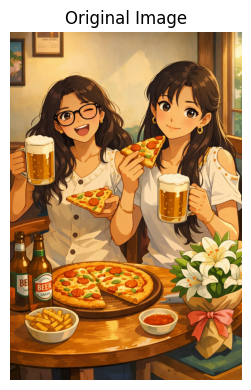

Image Format : PNG
Image Size   : (1024, 1536)
Image Mode   : RGB
Array Shape  : (1536, 1024, 3)


In [101]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Read using Pillow
image_colored   = Image.open('color_image.png')
image_arr_color = np.array(image_colored)

# Display with matplotlib
plt.figure(figsize=(5, 4))
plt.imshow(image_arr_color)
plt.title('Original Image')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Image Format : {image_colored.format}')
print(f'Image Size   : {image_colored.size}')
print(f'Image Mode   : {image_colored.mode}')
print(f'Array Shape  : {image_arr_color.shape}')

### 2. Display only the top left corner of 100x100 pixels.

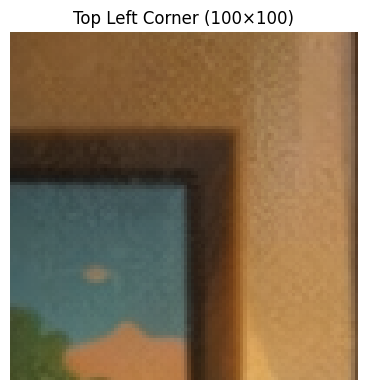

Top-left region shape: (100, 100, 3)


In [104]:
# NumPy array slicing: rows 0-99, cols 0-99, all channels
top_left_100 = image_arr_color[:100, :100, :]

plt.figure(figsize=(4, 4))
plt.imshow(top_left_100)
plt.title('Top Left Corner (100×100)')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Top-left region shape: {top_left_100.shape}')

### 3. Show the three color channels (R, G, B).


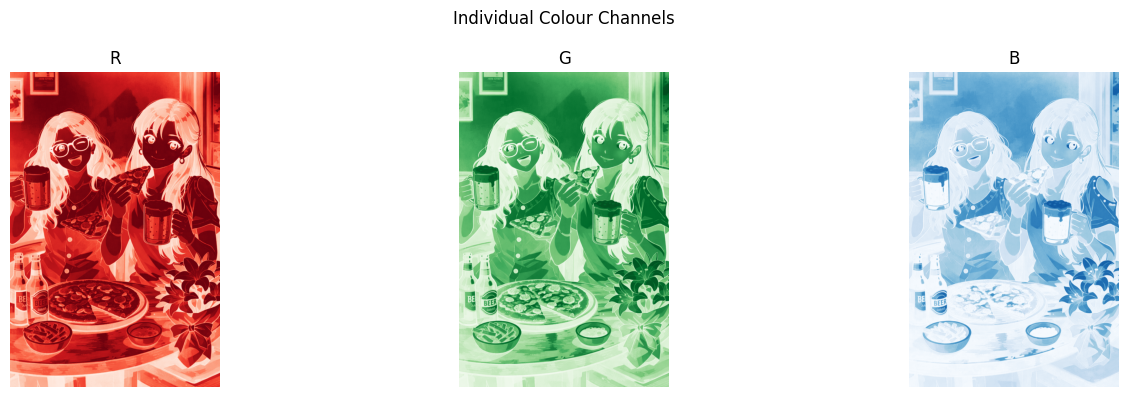

Red channel range   : 3 – 255
Green channel range : 0 – 253
Blue channel range  : 0 – 251


In [105]:
# Separate using NumPy indexing
red_channel   = image_arr_color[:, :, 0]   # index 0 = Red
green_channel = image_arr_color[:, :, 1]   # index 1 = Green
blue_channel  = image_arr_color[:, :, 2]   # index 2 = Blue

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(red_channel,   cmap='Reds');  axes[0].set_title('R');  axes[0].axis('off')
axes[1].imshow(green_channel, cmap='Greens'); axes[1].set_title('G'); axes[1].axis('off')
axes[2].imshow(blue_channel,  cmap='Blues');  axes[2].set_title('B'); axes[2].axis('off')

plt.suptitle('Individual Colour Channels')
plt.tight_layout()
plt.show()

print('Red channel range   :', red_channel.min(),   '–', red_channel.max())
print('Green channel range :', green_channel.min(), '–', green_channel.max())
print('Blue channel range  :', blue_channel.min(),  '–', blue_channel.max())

### 4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:

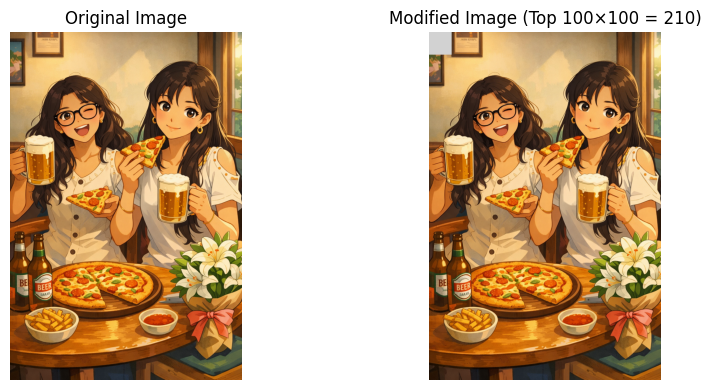

Pixel at (50,50) before: [59 64 62]
Pixel at (50,50) after : [210 210 210]


In [106]:
modified_arr = image_arr_color.copy()

# Set all three channels in top-left 100×100 region to 210 (light grey)
modified_arr[:100, :100, :] = 210

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image_arr_color); axes[0].set_title('Original Image');                    axes[0].axis('off')
axes[1].imshow(modified_arr);    axes[1].set_title('Modified Image (Top 100×100 = 210)'); axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f'Pixel at (50,50) before: {image_arr_color[50, 50, :]}')
print(f'Pixel at (50,50) after : {modified_arr[50, 50, :]}')

### Output of Exercise 1

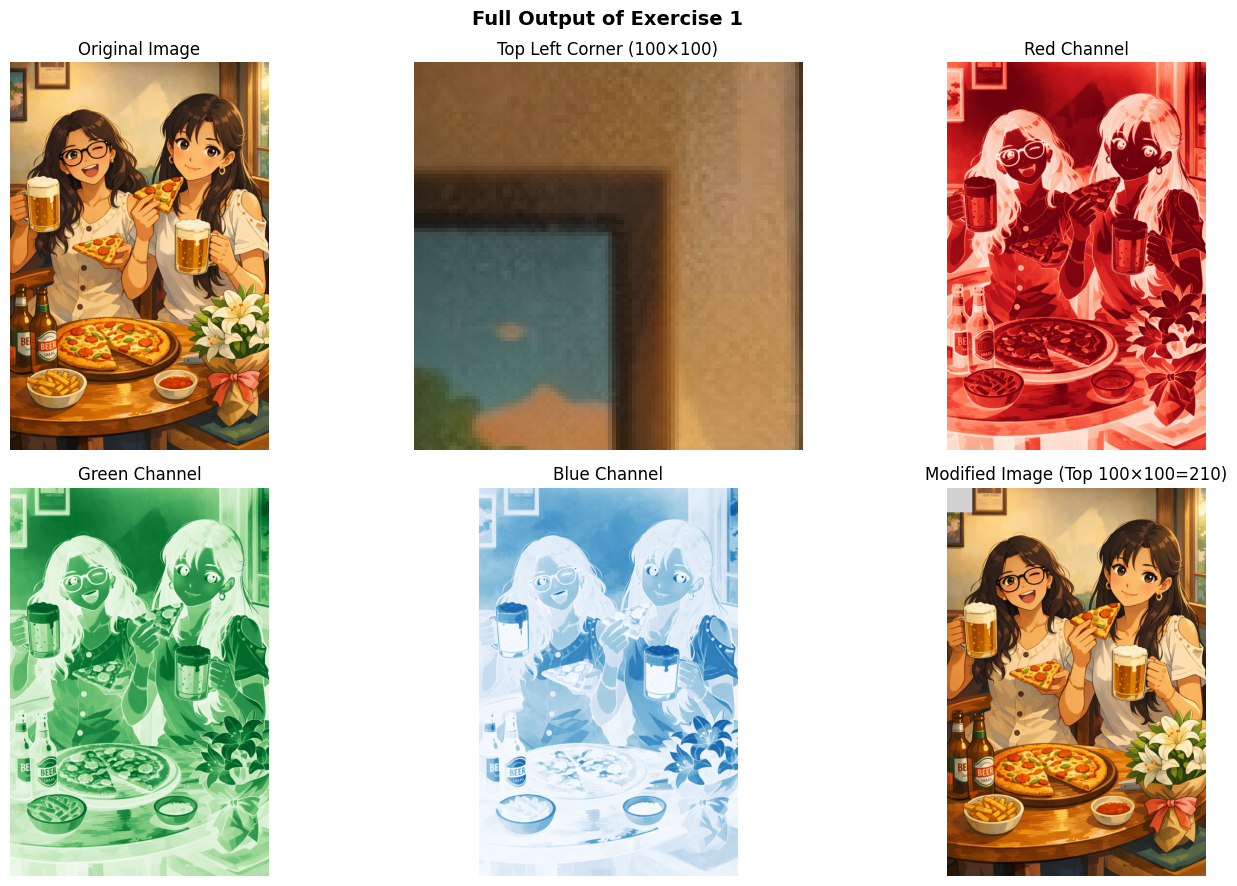

In [110]:
# Full Output

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0,0].imshow(image_arr_color);            axes[0,0].set_title('Original Image');                  axes[0,0].axis('off')
axes[0,1].imshow(top_left_100);               axes[0,1].set_title('Top Left Corner (100×100)');       axes[0,1].axis('off')
axes[0,2].imshow(red_channel,   cmap='Reds'); axes[0,2].set_title('Red Channel');                     axes[0,2].axis('off')
axes[1,0].imshow(green_channel, cmap='Greens');axes[1,0].set_title('Green Channel');                  axes[1,0].axis('off')
axes[1,1].imshow(blue_channel,  cmap='Blues'); axes[1,1].set_title('Blue Channel');                   axes[1,1].axis('off')
axes[1,2].imshow(modified_arr);               axes[1,2].set_title('Modified Image (Top 100×100=210)');axes[1,2].axis('off')

plt.suptitle('Full Output of Exercise 1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Exercise 2: Grayscale Image Operations


### 1. Load and display a grayscale image.


Image Format : None
Image Size   : (1024, 1536)
Image Mode   : L
Image shape  : (1536, 1024, 1)
Image pixels : 1572864


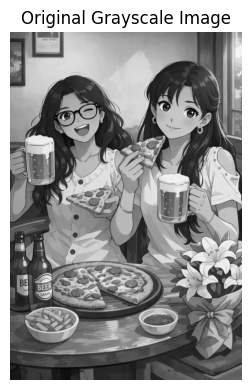

In [111]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image using Pillow
image_grayed   = Image.open('grayscale_image.png').convert('L')
image_arr_gray = np.array(image_grayed)

print(f'Image Format : {image_grayed.format}')
print(f'Image Size   : {image_grayed.size}')
print(f'Image Mode   : {image_grayed.mode}')

width, height = image_grayed.size
channels      = len(image_grayed.getbands())
print(f'Image shape  : ({height}, {width}, {channels})')
print(f'Image pixels : {width * height * channels}')

plt.figure(figsize=(5, 4))
plt.imshow(image_arr_gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.tight_layout()
plt.show()

### 2. Extract and display the middle section of the image (150 pixels).


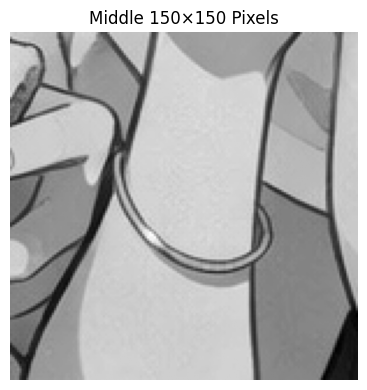

Middle section shape: (150, 150)


In [112]:
h, w   = image_arr_gray.shape
ctr_r  = h // 2
ctr_c  = w // 2

# NumPy array slicing around centre
middle_section = image_arr_gray[ctr_r - 75 : ctr_r + 75,
                                ctr_c - 75 : ctr_c + 75]

plt.figure(figsize=(4, 4))
plt.imshow(middle_section, cmap='gray')
plt.title('Middle 150×150 Pixels')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Middle section shape: {middle_section.shape}')

### 3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).


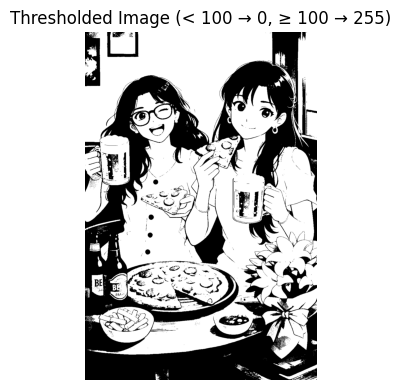

Unique pixel values after thresholding: [  0 255]


In [113]:
thresholded = image_arr_gray.copy()
thresholded[thresholded <  100] = 0
thresholded[thresholded >= 100] = 255

plt.figure(figsize=(5, 4))
plt.imshow(thresholded, cmap='gray')
plt.title('Thresholded Image (< 100 → 0, ≥ 100 → 255)')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Unique pixel values after thresholding: {np.unique(thresholded)}')

### 4. Rotate the image 90 degrees clockwise and display the result.


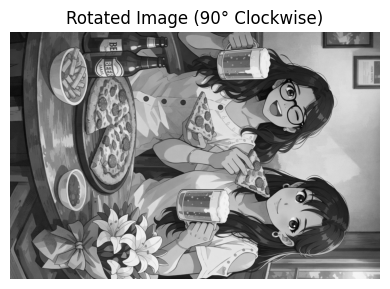

Original shape : (1536, 1024)
Rotated shape  : (1024, 1536)


In [114]:
# Pillow rotate() is counter-clockwise, so -90 = 90° clockwise
rotated_img = image_grayed.rotate(-90, expand=True)
rotated_array = np.array(rotated_img)

plt.figure(figsize=(4, 5))
plt.imshow(rotated_array, cmap='gray')
plt.title('Rotated Image (90° Clockwise)')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Original shape : {image_arr_gray.shape}')
print(f'Rotated shape  : {rotated_array.shape}')

### 5. Convert the grayscale image to an RGB image.


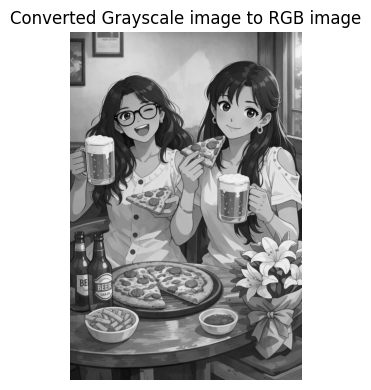

Grayscale shape : (1536, 1024)
RGB shape       : (1536, 1024, 3)


In [117]:
# Replicate grayscale values across R, G, B channels
rgb_from_gray = np.stack(
    [image_arr_gray, image_arr_gray, image_arr_gray],
    axis=2
)

plt.figure(figsize=(5, 4))
plt.imshow(rgb_from_gray)
plt.title('Converted Grayscale image to RGB image')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Grayscale shape : {image_arr_gray.shape}')
print(f'RGB shape       : {rgb_from_gray.shape}')

### Output of Exercise 2

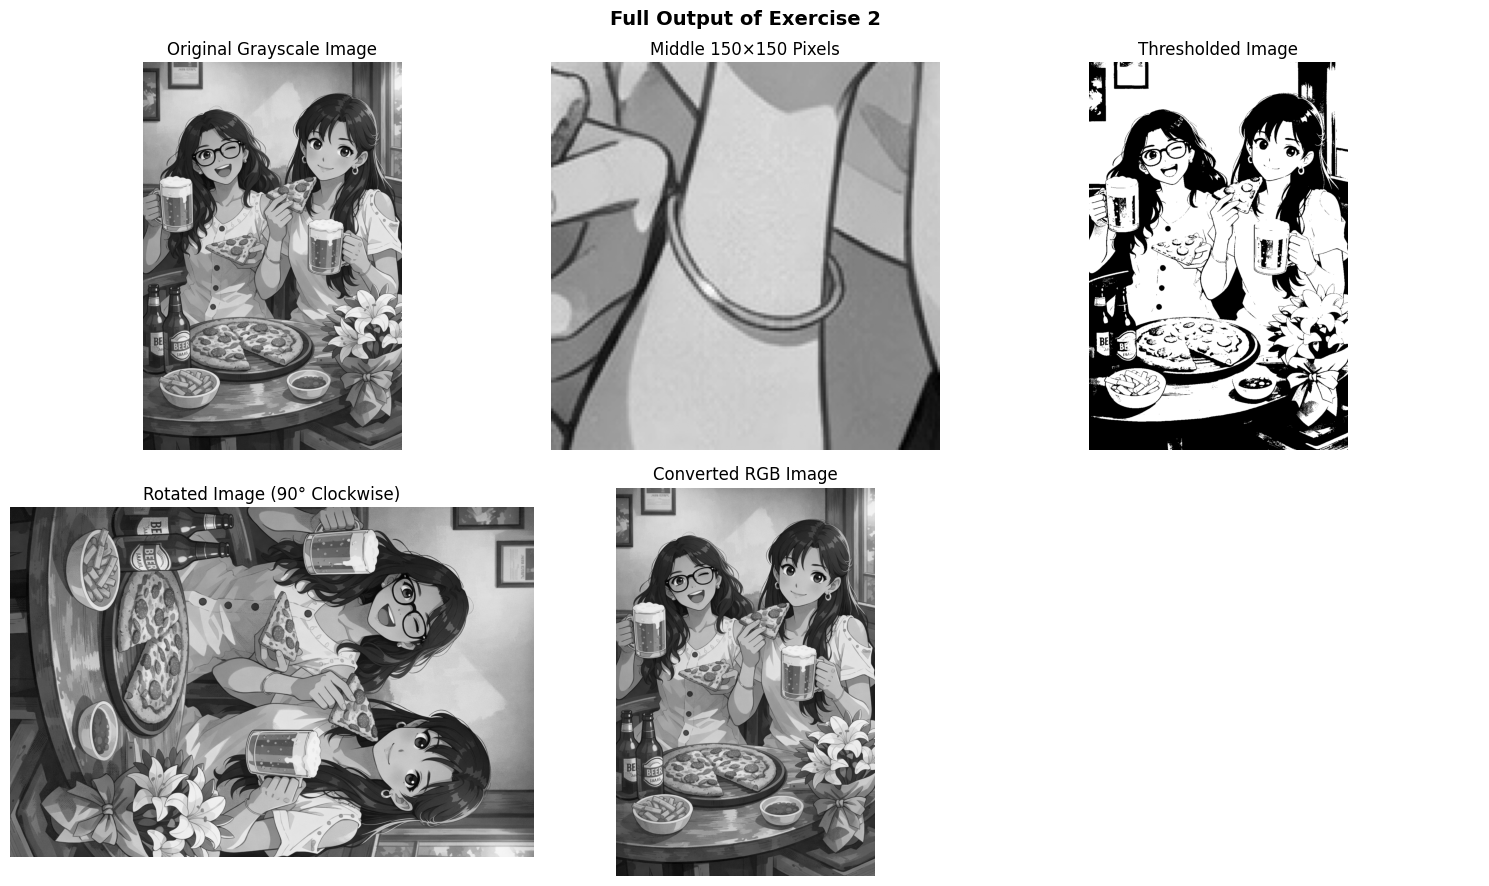

In [119]:
# Full Output
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0,0].imshow(image_arr_gray,  cmap='gray'); axes[0,0].set_title('Original Grayscale Image');     axes[0,0].axis('off')
axes[0,1].imshow(middle_section,  cmap='gray'); axes[0,1].set_title('Middle 150×150 Pixels');        axes[0,1].axis('off')
axes[0,2].imshow(thresholded,     cmap='gray'); axes[0,2].set_title('Thresholded Image');             axes[0,2].axis('off')
axes[1,0].imshow(rotated_array,   cmap='gray'); axes[1,0].set_title('Rotated Image (90° Clockwise)'); axes[1,0].axis('off')
axes[1,1].imshow(rgb_from_gray);                axes[1,1].set_title('Converted RGB Image');           axes[1,1].axis('off')
axes[1,2].axis('off')

plt.suptitle('Full Output of Exercise 2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Exercise 3: Image Compression & Decompression using PCA


### 1. Load and Prepare Data:


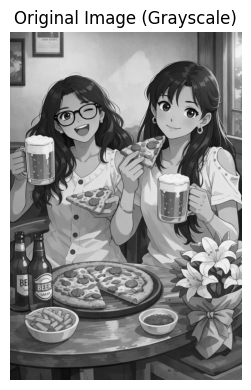

Image dimensions (height × width): 1536 × 1024
Data matrix shape: (1536, 1024)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load colour image, convert to grayscale for PCA
image_pca       = Image.open('color_image.png').convert('L')
image_arr_pca   = np.array(image_pca, dtype=np.float64)
height, width   = image_arr_pca.shape

data = image_arr_pca.reshape(height, width)

plt.figure(figsize=(5, 4))
plt.imshow(image_arr_pca, cmap='gray')
plt.title('Original Image (Grayscale)')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Image dimensions (height × width): {height} × {width}')
print(f'Data matrix shape: {data.shape}')

In [7]:
# Compute column-wise mean
mean = np.mean(data, axis=0)

# Subtract mean to centre the data around zero
centered_data = data - mean

print(f'Mean vector shape     : {mean.shape}')
print(f'Centered data shape   : {centered_data.shape}')
print(f'Mean after centering (≈0): {np.mean(centered_data):.8f}')

Mean vector shape     : (1024,)
Centered data shape   : (1536, 1024)
Mean after centering (≈0): 0.00000000


In [8]:
# Compute Covariance Matrix
cov_matrix = np.cov(centered_data, rowvar=False)

print(f'Covariance matrix shape    : {cov_matrix.shape}')
print(f'Matrix is symmetric        : {np.allclose(cov_matrix, cov_matrix.T)}')
print(f'Diagonal elements (sample) : {np.diag(cov_matrix)[:5].round(2)}')

Covariance matrix shape    : (1024, 1024)
Matrix is symmetric        : True
Diagonal elements (sample) : [1689.31 1698.95 1697.36 1718.48 1733.57]


### 2. Eigen Decomposition and Identifying Principal Components:

In [15]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding tothe highest eigenvalues.

sorted_indices = np.argsort(eigenvalues)[::-1]

# Compute Eigen Values and Eigen Vectors
eigenvalues    = eigenvalues[sorted_indices]
eigenvectors   = eigenvectors[:, sorted_indices]

print(f'Eigenvalues shape  : {eigenvalues.shape}')
print(f'Eigenvectors shape : {eigenvectors.shape}')
print(f'Top 5 eigenvalues  : {eigenvalues[:5].round(2)}')

Eigenvalues shape  : (1024,)
Eigenvectors shape : (1024, 1024)
Top 5 eigenvalues  : [799959.59 567803.02 376083.31 260353.48 210076.61]


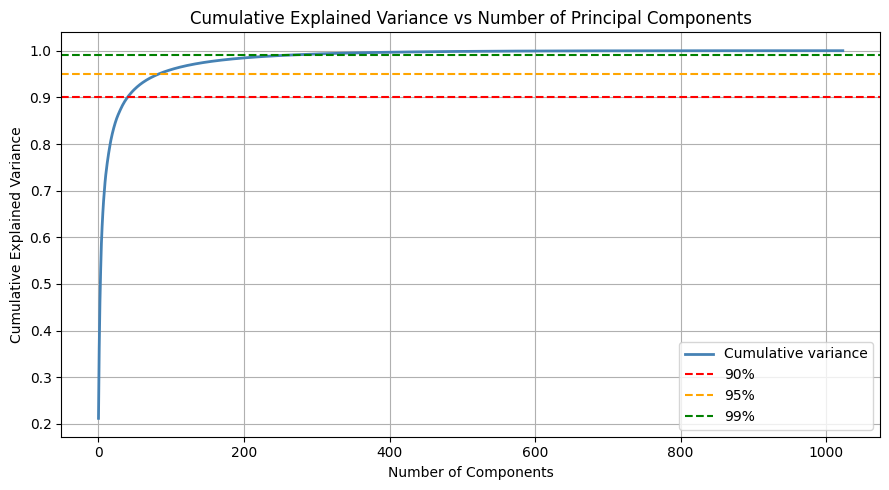

Components for 80% variance: 18
Components for 90% variance: 41
Components for 95% variance: 84
Components for 99% variance: 255


In [16]:
# Identify the Principal Components with the help of cumulative Sum plot.
explained_var_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_var      = np.cumsum(explained_var_ratio)

plt.figure(figsize=(9, 5))
plt.plot(cumulative_var, color='steelblue', linewidth=2, label='Cumulative variance')
plt.axhline(0.90, color='red',    linestyle='--', label='90%')
plt.axhline(0.95, color='orange', linestyle='--', label='95%')
plt.axhline(0.99, color='green',  linestyle='--', label='99%')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of Principal Components')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

for threshold in [0.80, 0.90, 0.95, 0.99]:
    n = np.argmax(cumulative_var >= threshold) + 1
    print(f'Components for {int(threshold*100)}% variance: {n}')

### 3. Reconstruction and Experiment:

In [18]:
def pca_compress_reconstruct(centered_data, eigenvectors, eigenvalues, mean, k):
    """
    Compress and reconstruct an image using the top-k principal components.
    Returns:
        compressed    : (height × k)
        reconstructed : (height × width)
        explained_var : fraction of total variance captured
    """
    # Select top k eigenvectors (columns)
    components = eigenvectors[:, :k] # shape: (width, k)

    # Compress
    compressed = np.dot(centered_data, components) # shape: (height, k)

    # Reconstruct and restore mean
    reconstructed = np.dot(compressed, components.T) + mean  # shape: (height, width)
    reconstructed = np.clip(reconstructed, 0, 255)

    explained_var = eigenvalues[:k].sum() / eigenvalues.sum()
    return compressed, reconstructed, explained_var

In [22]:
# Different k Values

k_values = [10, 20, 50, 100, 150]
results  = {}

for k in k_values:
    comp, rec, var = pca_compress_reconstruct(
        centered_data, eigenvectors, eigenvalues, mean, k
    )
    results[k] = {'compressed': comp, 'reconstructed': rec, 'var': var}
    mse = np.mean((image_arr_pca - rec) ** 2)
    ratio = (height * width) / (height * k + width * k)
    print(f'k={k:4d} | Var: {var*100:5.1f}% | MSE: {mse:8.3f} | Compression: {ratio:.2f}x')

k=  10 | Var:  71.8% | MSE: 1038.028 | Compression: 61.44x
k=  20 | Var:  82.2% | MSE:  654.108 | Compression: 30.72x
k=  50 | Var:  91.7% | MSE:  307.242 | Compression: 12.29x
k= 100 | Var:  95.9% | MSE:  150.348 | Compression: 6.14x
k= 150 | Var:  97.6% | MSE:   89.110 | Compression: 4.10x


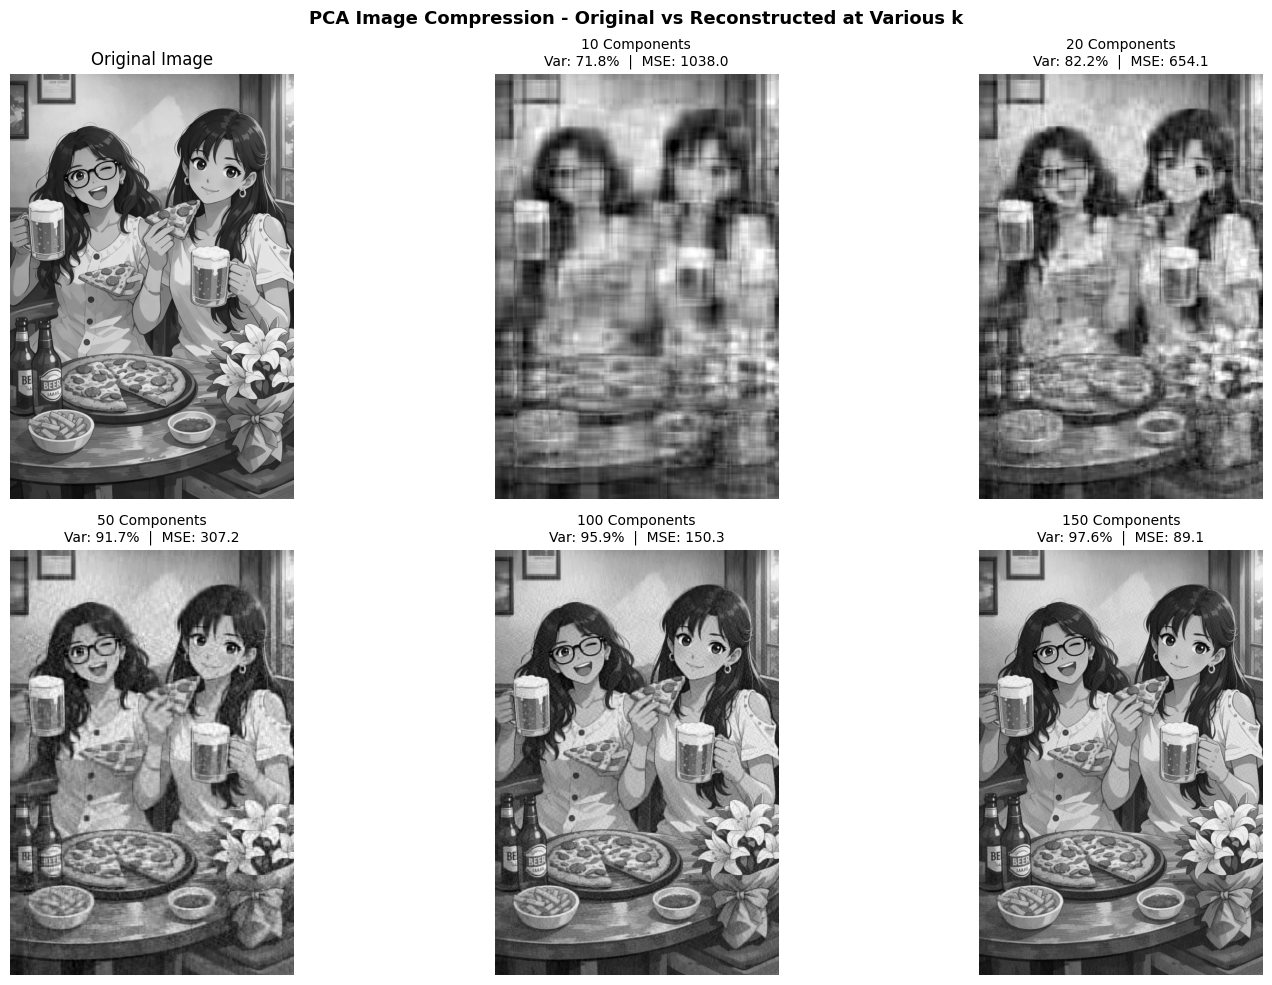

In [14]:
# Display & Evaluate Results

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

axes[0].imshow(image_arr_pca, cmap='gray')
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')

for i, k in enumerate(k_values):
    rec = results[k]['reconstructed']
    var = results[k]['var']
    mse = np.mean((image_arr_pca - rec) ** 2)
    axes[i+1].imshow(rec, cmap='gray')
    axes[i+1].set_title(f'{k} Components\nVar: {var*100:.1f}%  |  MSE: {mse:.1f}', fontsize=10)
    axes[i+1].axis('off')

plt.suptitle('PCA Image Compression - Original vs Reconstructed at Various k',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

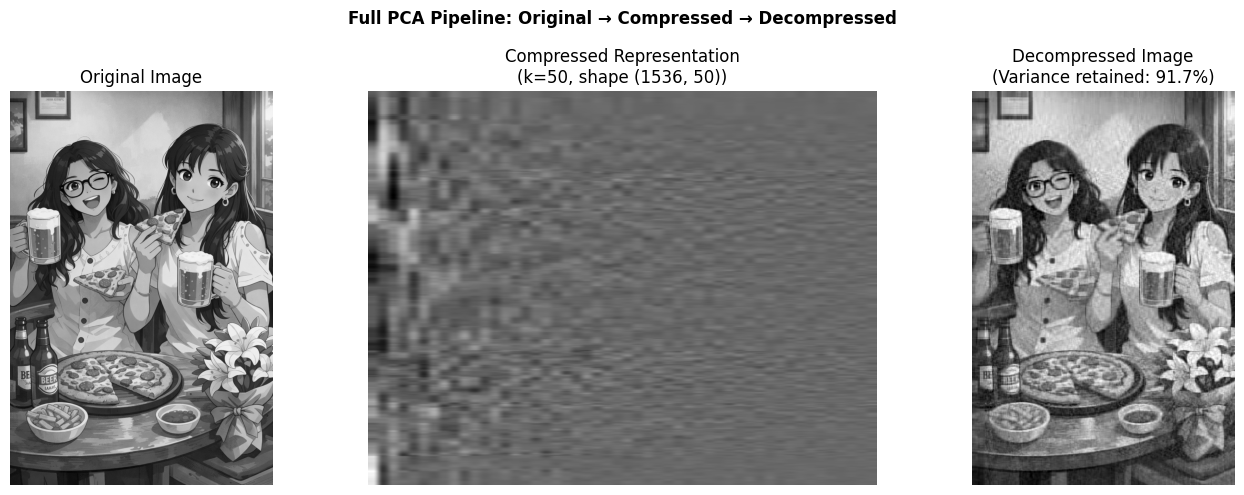

Original size    : 1536 × 1024 = 1572864 values
Compressed size  : 1536 × 50 + 1024 × 50 = 128000 values
Compression ratio: 12.29x


In [20]:
# (Original → Compressed → Decompressed)

k_demo = 50
comp_demo, decomp_demo, var_demo = pca_compress_reconstruct(
    centered_data, eigenvectors, eigenvalues, mean, k_demo
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image_arr_pca, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(comp_demo, cmap='gray', aspect='auto')
axes[1].set_title(f'Compressed Representation\n(k={k_demo}, shape {comp_demo.shape})')
axes[1].axis('off')

axes[2].imshow(decomp_demo, cmap='gray')
axes[2].set_title(f'Decompressed Image\n(Variance retained: {var_demo*100:.1f}%)')
axes[2].axis('off')

plt.suptitle('Full PCA Pipeline: Original → Compressed → Decompressed', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Original size    : {height} × {width} = {height*width} values')
print(f'Compressed size  : {height} × {k_demo} + {width} × {k_demo} = {height*k_demo + width*k_demo} values')
print(f'Compression ratio: {height*width / (height*k_demo + width*k_demo):.2f}x')

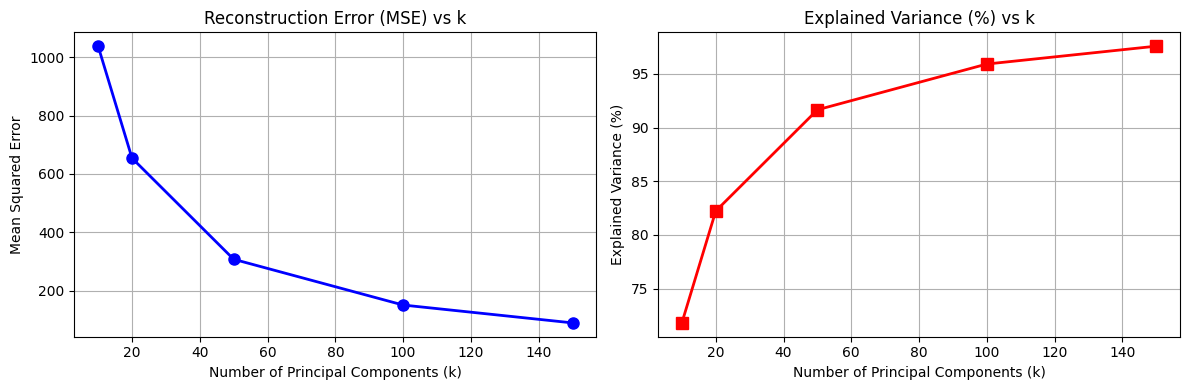

In [21]:
# Evaluation Plots

mse_list = [np.mean((image_arr_pca - results[k]['reconstructed'])**2) for k in k_values]
var_list = [results[k]['var'] * 100 for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_values, mse_list, 'bo-', lw=2, ms=8)
axes[0].set_title('Reconstruction Error (MSE) vs k')
axes[0].set_xlabel('Number of Principal Components (k)')
axes[0].set_ylabel('Mean Squared Error')
axes[0].grid(True)

axes[1].plot(k_values, var_list, 'rs-', lw=2, ms=8)
axes[1].set_title('Explained Variance (%) vs k')
axes[1].set_xlabel('Number of Principal Components (k)')
axes[1].set_ylabel('Explained Variance (%)')
axes[1].grid(True)

plt.tight_layout()
plt.show()